In [4]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator

data=pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/flipkart_reviews.csv")
print(data.head())

                                        Product_name  \
0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                              Review  Rating  
0  Best under 60k Great performanceI got it for a...       5  
1                                 Good perfomence...       5  
2  Great performance but usually it has also that...       5  
3           My wife is so happy and best product 👌🏻😘       5  
4  Light weight laptop with new amazing features,...       5  


In [5]:
print(data.isnull().sum())

Product_name    0
Review          0
Rating          0
dtype: int64


In [7]:
import nltk
import re
nltk.download('stopword')
stemmer=nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
import string
stopword=set(stopwords.words('english'))

def clean(text):
    text=str(text).lower()
    text=re.sub('\[.*?\]','',text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

data["Review"]=data["Review"].apply(clean)

<>:11: SyntaxWarning: invalid escape sequence '\['
<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\w'
<>:11: SyntaxWarning: invalid escape sequence '\['
<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\w'
C:\Users\chauh\AppData\Local\Temp\ipykernel_36304\868624102.py:11: SyntaxWarning: invalid escape sequence '\['
  text=re.sub('\[.*?\]','',text)
C:\Users\chauh\AppData\Local\Temp\ipykernel_36304\868624102.py:12: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
C:\Users\chauh\AppData\Local\Temp\ipykernel_36304\868624102.py:16: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)
[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index


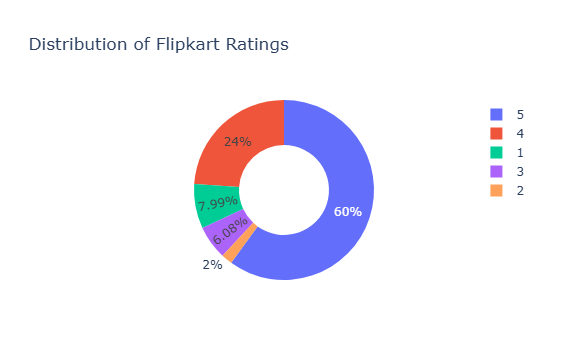

In [12]:
ratings=data["Rating"].value_counts()
import plotly.express as px

# Assuming 'ratings' is a Series where index = stars and values = counts
numbers = ratings.index
quantity = ratings.values

# Create the figure using the summarized arrays directly
figure = px.pie(values=quantity, 
               names=numbers, 
               hole=0.5,
               title="Distribution of Flipkart Ratings")

figure.show()

In [13]:
data.shape

(2304, 3)

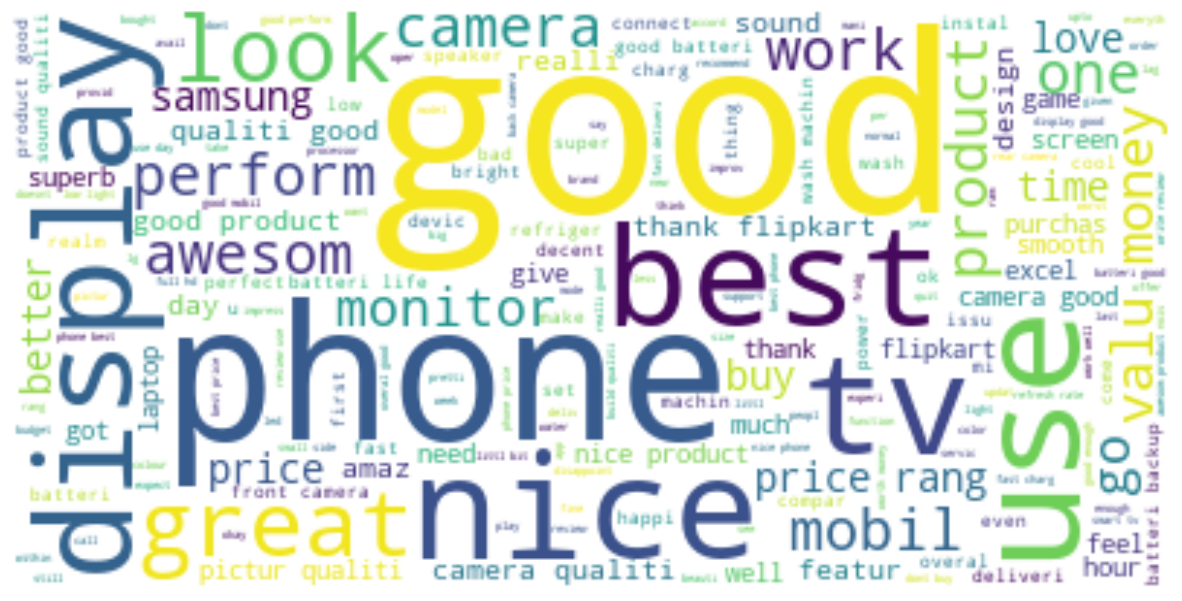

In [17]:
text=" ".join(i for i in data.Review)
stopwords=set(STOPWORDS)
wordcloud=WordCloud(stopwords=stopwords,background_color="white").generate(text)

plt.figure(figsize=(15,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [21]:
# nltk.download('vander_lexicon')
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Fix the spelling here: 'vader_lexicon' instead of 'vander'
nltk.download('vader_lexicon')

sentiments = SentimentIntensityAnalyzer()
# sentiments=SentimentIntensityAnalyzer()
sentiments = SentimentIntensityAnalyzer()
data["Positive"]=[sentiments.polarity_scores(i)["pos"] for i in data["Review"]]
data["Negative"]=[sentiments.polarity_scores(i)["neg"] for i in data["Review"]]
data["Netural"]=[sentiments.polarity_scores(i)["neu"] for i in data["Review"]]
data=data[["Review","Positive","Negative","Netural"]]
print(data.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\chauh\AppData\Roaming\nltk_data...


                                              Review  Positive  Negative  \
0  best  great performancei got around  backup bi...     0.395     0.101   
1                                        good perfom     0.744     0.000   
2  great perform usual also game laptop issu batt...     0.277     0.000   
3                        wife happi best product 👌🏻😘     0.512     0.000   
4  light weight laptop new amaz featur batteri li...     0.000     0.000   

   Netural  
0    0.504  
1    0.256  
2    0.723  
3    0.488  
4    1.000  


In [24]:
# x=sum(data["Positive"])
# y=sum(data["Negative"])
# z=sum(data["Neutral"])

# def sentiment_score(a,b,c):
#     if (a>b) and (a>c):
#         print("Positive")
#     elif (b>a) and (b>c):
#         print("Negative")
#     else:
#         print("Neutral")

# sentiment_score(x,y,z)

# 1. First, create the Neutral column (the step that was missing)
data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data["Review"]]

# 2. Now you can sum them up without the KeyError
x = sum(data["Positive"])
y = sum(data["Negative"])
z = sum(data["Neutral"])

print(f"Positive: {x}, Negative: {y}, Neutral: {z}")

C:\Users\chauh\AppData\Local\Temp\ipykernel_36304\3967463058.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Positive: 923.553, Negative: 96.775, Neutral: 1283.688


In [25]:
def sentiment_score(a, b, c):
    if (a > b) and (a > c):
        print("Overall Sentiment: Positive 😊")
    elif (b > a) and (b > c):
        print("Overall Sentiment: Negative 😡")
    else:
        print("Overall Sentiment: Neutral 😐")

sentiment_score(x, y, z)

Overall Sentiment: Neutral 😐


In [26]:
print("Positive: ", x)
print("Negative: ", y)
print("Neutral: ", z)

Positive:  923.553
Negative:  96.775
Neutral:  1283.688
